# Comprehensive Analysis of Student Depression

**Objective:** Conduct a complete exploratory data analysis and statistical investigation into the factors contributing to depression among students.

**Dataset:** Student mental health and depression survey data. [Dataset](https://github.com/user-attachments/files/26166744/student_depression_dataset.csv)

**Scope:** This analysis encompasses data profiling, cleaning, feature understanding, exploratory analysis, statistical hypothesis testing, and preparation for predictive modeling.

# Introduction

Student depression represents a significant public health concern requiring data-driven intervention strategies. This analysis examines the relationships between demographic, academic, lifestyle, and psychological factors and depression prevalence among students.

**Primary Research Questions:**
- Which factors most strongly associate with student depression?
- Can depression be predicted from survey responses?
- What patterns emerge from statistical and machine learning analyses?


# Notebook Setup

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Section 1 : Data Loading & Initial Overview

### Objective
Load the dataset and obtain fundamental information about its structure, dimensions, and data types.


In [2]:
# Load the dataset
df = pd.read_csv('/content/student_depression_dataset.csv')

# Display basic information
print("="*80)
print("DATASET DIMENSIONS")
print("="*80)
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("First Few Records:")
print("=" * 80)
df.head()

DATASET DIMENSIONS
Rows: 27,901
Columns: 18
First Few Records:


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


In [3]:
# Display column names and target distribution
print("="*80)
print("COLUMN NAMES & DATA TYPES")
print("="*80)
print(df.dtypes)

print("\n" + "=" * 80)
print("TARGET VARIABLE DISTRIBUTION:")
print("=" * 80)
print(df['Depression'].value_counts())
print(f"\nClass Distribution: {df['Depression'].value_counts(normalize=True).values}")
print(f"Depression Rate: {(df['Depression'].sum() / len(df) * 100):.2f}%")

COLUMN NAMES & DATA TYPES
id                                         int64
Gender                                    object
Age                                      float64
City                                      object
Profession                                object
Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Sleep Duration                            object
Dietary Habits                            object
Degree                                    object
Have you ever had suicidal thoughts ?     object
Work/Study Hours                         float64
Financial Stress                          object
Family History of Mental Illness          object
Depression                                 int64
dtype: object

TARGET VARIABLE DISTRIBUTION:
Depression
1    16336
0    11565
Name: count, d

# Section 2 : Data Profiling

### Objective
Understand the structure, completeness, and quality of each feature through statistical summaries, missing value analysis, and data type validation.


In [4]:
# Missing values analysis
print("=" * 80)
print("MISSING VALUES ANALYSIS:")
print("=" * 80)

missing_data = pd.DataFrame({
    'Feature': df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percentage': (df.isnull().sum().values / len(df) * 100).round(2)
})
print(missing_data)

# Summary statistics for numerical columns
print("\n" + "=" * 80)
print("NUMERICAL FEATURES - SUMMARY STATISTICS:")
print("=" * 80)
print(df.describe().round(3))

MISSING VALUES ANALYSIS:
                                  Feature  Missing_Count  Missing_Percentage
0                                      id              0                 0.0
1                                  Gender              0                 0.0
2                                     Age              0                 0.0
3                                    City              0                 0.0
4                              Profession              0                 0.0
5                       Academic Pressure              0                 0.0
6                           Work Pressure              0                 0.0
7                                    CGPA              0                 0.0
8                      Study Satisfaction              0                 0.0
9                        Job Satisfaction              0                 0.0
10                         Sleep Duration              0                 0.0
11                         Dietary Habits          

In [5]:
# Target variable distribution
print("="*80)
print("TARGET VARIABLE: DEPRESSION")
print("="*80)
depression_counts = df['Depression'].value_counts().sort_index()
print(depression_counts)
print()
print("Percentage Distribution:")
print(df['Depression'].value_counts(normalize=True).sort_index() * 100)
print()
print(f"Class Balance: {depression_counts[0]} (No Depression) vs {depression_counts[1]} (Depression)")
print(f"Imbalance Ratio: {depression_counts[1]/depression_counts[0]:.2f}")

TARGET VARIABLE: DEPRESSION
Depression
0    11565
1    16336
Name: count, dtype: int64

Percentage Distribution:
Depression
0    41.450127
1    58.549873
Name: proportion, dtype: float64

Class Balance: 11565 (No Depression) vs 16336 (Depression)
Imbalance Ratio: 1.41


In [6]:
# Unique values and categorical feature analysis
print("\n" + "=" * 80)
print("CATEGORICAL FEATURES - UNIQUE VALUES:")
print("=" * 80)

categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  Unique values: {df[col].nunique()}")
    print(f"  Values: {df[col].unique()[:10]}")  # Show first 10
    print(f"  Distribution:\n{df[col].value_counts()}")

# Check for data type issues (e.g., numeric stored as strings)
print("\n" + "=" * 80)
print("DATA QUALITY CHECKS:")
print("=" * 80)
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Rows with all NaN: {df.isnull().all(axis=1).sum()}")


CATEGORICAL FEATURES - UNIQUE VALUES:

Gender:
  Unique values: 2
  Values: ['Male' 'Female']
  Distribution:
Gender
Male      15547
Female    12354
Name: count, dtype: int64

City:
  Unique values: 52
  Values: ['Visakhapatnam' 'Bangalore' 'Srinagar' 'Varanasi' 'Jaipur' 'Pune' 'Thane'
 'Chennai' 'Nagpur' 'Nashik']
  Distribution:
City
Kalyan                  1570
Srinagar                1372
Hyderabad               1340
Vasai-Virar             1290
Lucknow                 1155
Thane                   1139
Ludhiana                1111
Agra                    1094
Surat                   1078
Kolkata                 1066
Jaipur                  1036
Patna                   1007
Visakhapatnam            969
Pune                     968
Ahmedabad                951
Bhopal                   934
Chennai                  885
Meerut                   825
Rajkot                   816
Delhi                    768
Bangalore                767
Ghaziabad                745
Mumbai                 

# Section 3 : Data Cleaning & Preprocessing

### Objective
Ensure data integrity by handling missing values, fixing inconsistencies, and treating outliers with statistical justification.

### Cleaning Strategy:
1. **Handle missing values** with domain-appropriate methods
2. **Verify data types** and fix any inconsistencies
3. **Detect and address outliers** using statistical methods
4. **Validate value ranges** for each feature


In [7]:
# Create a copy for cleaning
df_clean = df.copy()

print("Starting data cleaning process...")
print(f"Initial shape: {df_clean.shape}")

Starting data cleaning process...
Initial shape: (27901, 18)


### Step 1: Drop ID Column
**Issue**: ID is just a unique identifier, not a feature for prediction.
**Action**: Remove the 'id' column.
**Why**: ID columns don't contribute to model training and can cause data leakage issues.

In [8]:
# Remove ID column
df_clean = df_clean.drop('id', axis=1)

print("✓ Dropped 'id' column")
print(f"New shape: {df_clean.shape}")

✓ Dropped 'id' column
New shape: (27901, 17)


### Step 2: Clean Financial_Stress
**Issue**: Stored as string instead of numeric; contains '?' for invalid values.
**Current values**: ['1.0', '2.0', '5.0', '3.0', '4.0', '?']
**Action**:
  1. Replace '?' with NaN
  2. Convert to numeric
  3. Fill NaN with median (preserves distribution and imputes missing values)
**Why**: Models cannot work with string numbers or missing indicators like '?'.

In [9]:
# Check Financial Stress before cleaning
print("BEFORE CLEANING:")
print(f"Data type: {df_clean['Financial Stress'].dtype}")
print(f"Unique values: {sorted(df_clean['Financial Stress'].unique())}")
print(f"Value counts:\n{df_clean['Financial Stress'].value_counts()}")
print()

# Clean Financial Stress
# Replace '?' with NaN
df_clean['Financial Stress'] = df_clean['Financial Stress'].replace('?', np.nan)

# Convert to numeric
df_clean['Financial Stress'] = pd.to_numeric(df_clean['Financial Stress'], errors='coerce')

# Fill NaN with median
median_financial_stress = df_clean['Financial Stress'].median()
df_clean['Financial Stress'] = df_clean['Financial Stress'].fillna(median_financial_stress)

print("AFTER CLEANING:")
print(f"Data type: {df_clean['Financial Stress'].dtype}")
print(f"Unique values: {sorted(df_clean['Financial Stress'].unique())}")
print(f"Min: {df_clean['Financial Stress'].min()}, Max: {df_clean['Financial Stress'].max()}")
print(f"Median (used for imputation): {median_financial_stress}")
print(f"No missing values: {df_clean['Financial Stress'].isnull().sum() == 0}")

BEFORE CLEANING:
Data type: object
Unique values: ['1.0', '2.0', '3.0', '4.0', '5.0', '?']
Value counts:
Financial Stress
5.0    6715
4.0    5775
3.0    5226
1.0    5121
2.0    5061
?         3
Name: count, dtype: int64

AFTER CLEANING:
Data type: float64
Unique values: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
Min: 1.0, Max: 5.0
Median (used for imputation): 3.0
No missing values: True


### Step 3: Clean Sleep Duration
**Issue**: Values are stored with extra quotes (e.g., ''5-6 hours'' instead of '5-6 hours').
**Current values**: ['5-6 hours', 'Less than 5 hours', '7-8 hours', 'More than 8 hours', 'Others']
**Action**:
  1. Remove surrounding quotes
  2. Standardize formatting
  3. Convert to meaningful numeric categories
**Why**: Extra quotes cause parsing issues; numeric encoding helps models interpret patterns in sleep.

In [10]:
# Check Sleep Duration before cleaning
print("BEFORE CLEANING:")
print(f"Data type: {df_clean['Sleep Duration'].dtype}")
print(f"Unique values: {df_clean['Sleep Duration'].unique()}")
print(f"Value counts:\n{df_clean['Sleep Duration'].value_counts()}")
print()

# Remove surrounding quotes
df_clean['Sleep Duration'] = df_clean['Sleep Duration'].str.strip("'")

# Map to numeric values (hours of sleep)
sleep_mapping = {
    'Less than 5 hours': 4.5,      # Midpoint below 5
    '5-6 hours': 5.5,              # Midpoint of 5-6
    '7-8 hours': 7.5,              # Midpoint of 7-8 (recommended)
    'More than 8 hours': 8.5,      # Midpoint above 8
    'Others': 6.0                  # Default midpoint for unknown
}
df_clean['Sleep Duration'] = df_clean['Sleep Duration'].map(sleep_mapping)

print("AFTER CLEANING:")
print(f"Data type: {df_clean['Sleep Duration'].dtype}")
print(f"Unique values: {sorted(df_clean['Sleep Duration'].unique())}")
print(f"Min: {df_clean['Sleep Duration'].min()}, Max: {df_clean['Sleep Duration'].max()}")
print(f"Value counts:\n{df_clean['Sleep Duration'].value_counts().sort_index()}")
print(f"No missing values: {df_clean['Sleep Duration'].isnull().sum() == 0}")

BEFORE CLEANING:
Data type: object
Unique values: ["'5-6 hours'" "'Less than 5 hours'" "'7-8 hours'" "'More than 8 hours'"
 'Others']
Value counts:
Sleep Duration
'Less than 5 hours'    8310
'7-8 hours'            7346
'5-6 hours'            6183
'More than 8 hours'    6044
Others                   18
Name: count, dtype: int64

AFTER CLEANING:
Data type: float64
Unique values: [np.float64(4.5), np.float64(5.5), np.float64(6.0), np.float64(7.5), np.float64(8.5)]
Min: 4.5, Max: 8.5
Value counts:
Sleep Duration
4.5    8310
5.5    6183
6.0      18
7.5    7346
8.5    6044
Name: count, dtype: int64
No missing values: True


### Step 4: Clean Dietary_Habits
**Issue**: 'Others' is a catchall category that hides meaning.
**Current values**: ['Healthy', 'Moderate', 'Unhealthy', 'Others']
**Action**:
  1. Replace 'Others' with the most common category ('Moderate' as neutral default)
  2. Convert to numeric ordinal encoding (importance order: Healthy > Moderate > Unhealthy)
**Why**: 'Others' provides no information; numeric encoding helps models learn dietary patterns.

In [11]:
# Check Dietary Habits before cleaning
print("BEFORE CLEANING:")
print(f"Data type: {df_clean['Dietary Habits'].dtype}")
print(f"Unique values: {df_clean['Dietary Habits'].unique()}")
print(f"Value counts:\n{df_clean['Dietary Habits'].value_counts()}")
print()

# Replace 'Others' with 'Moderate' (neutral category)
df_clean['Dietary Habits'] = df_clean['Dietary Habits'].replace('Others', 'Moderate')

# Convert to numeric ordinal encoding (higher = healthier)
dietary_mapping = {
    'Healthy': 3,
    'Moderate': 2,
    'Unhealthy': 1
}
df_clean['Dietary Habits'] = df_clean['Dietary Habits'].map(dietary_mapping)

print("AFTER CLEANING:")
print(f"Data type: {df_clean['Dietary Habits'].dtype}")
print(f"Unique values: {sorted(df_clean['Dietary Habits'].unique())}")
print(f"Value counts:\n{df_clean['Dietary Habits'].value_counts().sort_index()}")
print(f"No missing values: {df_clean['Dietary Habits'].isnull().sum() == 0}")

BEFORE CLEANING:
Data type: object
Unique values: ['Healthy' 'Moderate' 'Unhealthy' 'Others']
Value counts:
Dietary Habits
Unhealthy    10317
Moderate      9921
Healthy       7651
Others          12
Name: count, dtype: int64

AFTER CLEANING:
Data type: int64
Unique values: [np.int64(1), np.int64(2), np.int64(3)]
Value counts:
Dietary Habits
1    10317
2     9933
3     7651
Name: count, dtype: int64
No missing values: True


### Step 5: Convert Binary Categorical Features to Numeric
**Features**: Gender, Have you ever had suicidal thoughts?, Family History of Mental Illness
**Issue**: Binary features stored as strings; models work better with numeric encoding.
**Action**: Convert Yes/No and Male/Female to 0/1 encoding.
**Why**: Numeric encoding is more efficient for computation and helps models identify patterns.

In [12]:
# GENDER
print("GENDER:")
print(f"Before: {df_clean['Gender'].unique()}")
gender_mapping = {'Male': 1, 'Female': 0}
df_clean['Gender'] = df_clean['Gender'].map(gender_mapping)
print(f"After: {sorted(df_clean['Gender'].unique())}")
print(f"Mapping: Male=1, Female=0")
print()

# HAVE YOU EVER HAD SUICIDAL THOUGHTS
print("HAVE YOU EVER HAD SUICIDAL THOUGHTS:")
print(f"Before: {df_clean['Have you ever had suicidal thoughts ?'].unique()}")
suicidal_mapping = {'Yes': 1, 'No': 0}
df_clean['Have you ever had suicidal thoughts ?'] = df_clean['Have you ever had suicidal thoughts ?'].map(suicidal_mapping)
print(f"After: {sorted(df_clean['Have you ever had suicidal thoughts ?'].unique())}")
print(f"Mapping: Yes=1, No=0")
print()

# FAMILY HISTORY OF MENTAL ILLNESS
print("FAMILY HISTORY OF MENTAL ILLNESS:")
print(f"Before: {df_clean['Family History of Mental Illness'].unique()}")
family_history_mapping = {'Yes': 1, 'No': 0}
df_clean['Family History of Mental Illness'] = df_clean['Family History of Mental Illness'].map(family_history_mapping)
print(f"After: {sorted(df_clean['Family History of Mental Illness'].unique())}")
print(f"Mapping: Yes=1, No=0")

GENDER:
Before: ['Male' 'Female']
After: [np.int64(0), np.int64(1)]
Mapping: Male=1, Female=0

HAVE YOU EVER HAD SUICIDAL THOUGHTS:
Before: ['Yes' 'No']
After: [np.int64(0), np.int64(1)]
Mapping: Yes=1, No=0

FAMILY HISTORY OF MENTAL ILLNESS:
Before: ['No' 'Yes']
After: [np.int64(0), np.int64(1)]
Mapping: Yes=1, No=0


### Step 6: Verify Numeric Features
**Features**: Age, Academic Pressure, Work Pressure, CGPA, Study Satisfaction, Job Satisfaction, Work/Study Hours
**Issue**: Verify these are clean and in valid ranges.
**Action**: Check for outliers and validate ranges.
**Why**: Ensures data quality and identifies extreme values that might be errors.

In [13]:
# Check numeric features
numeric_features = ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
                    'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours']

print("="*80)
print("NUMERIC FEATURES - VALIDATION")
print("="*80)
for feature in numeric_features:
    print(f"\n{feature}:")
    print(f"  Data type: {df_clean[feature].dtype}")
    print(f"  Min: {df_clean[feature].min():.2f}")
    print(f"  Max: {df_clean[feature].max():.2f}")
    print(f"  Mean: {df_clean[feature].mean():.2f}")
    print(f"  Median: {df_clean[feature].median():.2f}")
    print(f"  Missing values: {df_clean[feature].isnull().sum()}")

NUMERIC FEATURES - VALIDATION

Age:
  Data type: float64
  Min: 18.00
  Max: 59.00
  Mean: 25.82
  Median: 25.00
  Missing values: 0

Academic Pressure:
  Data type: float64
  Min: 0.00
  Max: 5.00
  Mean: 3.14
  Median: 3.00
  Missing values: 0

Work Pressure:
  Data type: float64
  Min: 0.00
  Max: 5.00
  Mean: 0.00
  Median: 0.00
  Missing values: 0

CGPA:
  Data type: float64
  Min: 0.00
  Max: 10.00
  Mean: 7.66
  Median: 7.77
  Missing values: 0

Study Satisfaction:
  Data type: float64
  Min: 0.00
  Max: 5.00
  Mean: 2.94
  Median: 3.00
  Missing values: 0

Job Satisfaction:
  Data type: float64
  Min: 0.00
  Max: 4.00
  Mean: 0.00
  Median: 0.00
  Missing values: 0

Work/Study Hours:
  Data type: float64
  Min: 0.00
  Max: 12.00
  Mean: 7.16
  Median: 8.00
  Missing values: 0


### Step 7: Handle Categorical Features (City, Profession, Degree)
**Features**: City, Profession, Degree
**Issue**: High-cardinality categorical variables; too many unique values for direct encoding.
**Decision**: Keep as categorical for now; will handle in feature engineering for ML pipeline.
**Why**: These features need careful encoding to avoid curse of dimensionality.

In [14]:
categorical_features = ['City', 'Profession', 'Degree']

print("="*80)
print("HIGH-CARDINALITY CATEGORICAL FEATURES")
print("="*80)
for feature in categorical_features:
    print(f"\n{feature}:")
    print(f"  Unique values: {df_clean[feature].nunique()}")
    print(f"  Data type: {df_clean[feature].dtype}")
    print(f"  Sample values: {df_clean[feature].unique()[:5]}")
    print(f"  Top 5 categories:\n{df_clean[feature].value_counts().head()}")

HIGH-CARDINALITY CATEGORICAL FEATURES

City:
  Unique values: 52
  Data type: object
  Sample values: ['Visakhapatnam' 'Bangalore' 'Srinagar' 'Varanasi' 'Jaipur']
  Top 5 categories:
City
Kalyan         1570
Srinagar       1372
Hyderabad      1340
Vasai-Virar    1290
Lucknow        1155
Name: count, dtype: int64

Profession:
  Unique values: 14
  Data type: object
  Sample values: ['Student' "'Civil Engineer'" 'Architect' "'UX/UI Designer'"
 "'Digital Marketer'"]
  Top 5 categories:
Profession
Student               27870
Architect                 8
Teacher                   6
'Digital Marketer'        3
Chef                      2
Name: count, dtype: int64

Degree:
  Unique values: 28
  Data type: object
  Sample values: ['B.Pharm' 'BSc' 'BA' 'BCA' 'M.Tech']
  Top 5 categories:
Degree
'Class 12'    6080
B.Ed          1867
B.Com         1506
B.Arch        1478
BCA           1433
Name: count, dtype: int64


## Data Cleaning Summary

In [15]:
print("="*80)
print("DATA CLEANING SUMMARY")
print("="*80)
print(f"\nOriginal shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")
print()
print("CLEANING ACTIONS PERFORMED:")
print("  ✓ Dropped 'id' column (not a feature)")
print("  ✓ Cleaned 'Financial Stress': removed '?', converted to numeric, filled with median")
print("  ✓ Cleaned 'Sleep Duration': removed quotes, converted to numeric hours")
print("  ✓ Cleaned 'Dietary Habits': replaced 'Others' with 'Moderate', converted to ordinal")
print("  ✓ Converted 'Gender' to binary (Male=1, Female=0)")
print("  ✓ Converted 'Have you ever had suicidal thoughts ?' to binary (Yes=1, No=0)")
print("  ✓ Converted 'Family History of Mental Illness' to binary (Yes=1, No=0)")
print("  ✓ Verified all numeric features are valid")
print()
print(f"Total missing values after cleaning: {df_clean.isnull().sum().sum()}")
print()
print("DATA TYPES AFTER CLEANING:")
print(df_clean.dtypes)

DATA CLEANING SUMMARY

Original shape: (27901, 18)
Cleaned shape: (27901, 17)

CLEANING ACTIONS PERFORMED:
  ✓ Dropped 'id' column (not a feature)
  ✓ Cleaned 'Financial Stress': removed '?', converted to numeric, filled with median
  ✓ Cleaned 'Sleep Duration': removed quotes, converted to numeric hours
  ✓ Cleaned 'Dietary Habits': replaced 'Others' with 'Moderate', converted to ordinal
  ✓ Converted 'Gender' to binary (Male=1, Female=0)
  ✓ Converted 'Have you ever had suicidal thoughts ?' to binary (Yes=1, No=0)
  ✓ Converted 'Family History of Mental Illness' to binary (Yes=1, No=0)
  ✓ Verified all numeric features are valid

Total missing values after cleaning: 0

DATA TYPES AFTER CLEANING:
Gender                                     int64
Age                                      float64
City                                      object
Profession                                object
Academic Pressure                        float64
Work Pressure                            float64

# Section 4 : Feature Understanding & Categorization

### Objective
Organize features into conceptually meaningful groups to better understand their roles in depression outcomes.

### Feature Taxonomy:

**Demographic Features:** Provide context about the individual's background and location
- `id`: Record identifier (to be removed)
- `Gender`: Binary categorical (Male/Female)
- `Age`: Continuous, age in years
- `City`: Categorical, geographic location in India
- `Profession`: Categorical (primarily "Student")

**Academic Features:** Directly related to educational performance and stress
- `Degree`: Categorical, level and type of degree
- `CGPA`: Continuous, cumulative grade performance (range 0-10)
- `Academic Pressure`: Ordinal (1-5 scale), self-reported academic stress
- `Study Satisfaction`: Ordinal (1-5 scale), satisfaction with studies

**Work-Related Features:** Applicable to students with part-time/full-time work
- `Work Pressure`: Ordinal (1-5 scale or binary 0/1), occupational stress
- `Work/Study Hours`: Continuous, hours spent weekly
- `Job Satisfaction`: Ordinal (1-5 scale or binary), satisfaction with work

**Lifestyle Features:** Daily behaviors affecting mental health
- `Sleep Duration`: Categorical/Ordinal, self-reported sleep patterns
- `Dietary Habits`: Categorical (Healthy/Moderate/Unhealthy)

**Psychological Features:** Mental health risk indicators
- `Have you ever had suicidal thoughts ?`: Binary (Yes/No)
- `Family History of Mental Illness`: Binary (Yes/No)

**Target Variable:**
- `Depression`: Binary outcome (0 = No, 1 = Yes)


In [16]:
# Categorize features
numerical_features = [
    'Age',
    'Academic Pressure',
    'Work Pressure',
    'CGPA',
    'Study Satisfaction',
    'Job Satisfaction',
    'Sleep Duration',           # NOW NUMERIC (after cleaning)
    'Work/Study Hours',
    'Financial Stress'          # NOW NUMERIC (after cleaning)
]

binary_features = [
    'Gender',
    'Have you ever had suicidal thoughts ?',
    'Family History of Mental Illness'
]

categorical_features = [
    'City',
    'Profession',
    'Degree',
    'Dietary Habits'            # NOW NUMERIC ORDINAL (after cleaning)
]

target = 'Depression'

print("="*80)
print("FEATURE CATEGORIZATION")
print("="*80)
print()
print(f"Numerical Features ({len(numerical_features)}):")
for i, feat in enumerate(numerical_features, 1):
    print(f"  {i:2d}. {feat}")

print()
print(f"Binary Features ({len(binary_features)}):")
for i, feat in enumerate(binary_features, 1):
    print(f"  {i:2d}. {feat}")

print()
print(f"Categorical Features ({len(categorical_features)}):")
for i, feat in enumerate(categorical_features, 1):
    print(f"  {i:2d}. {feat}")

print()
print(f"Target Variable: {target}")
print()
print(f"Total Features: {len(numerical_features) + len(binary_features) + len(categorical_features)}")

FEATURE CATEGORIZATION

Numerical Features (9):
   1. Age
   2. Academic Pressure
   3. Work Pressure
   4. CGPA
   5. Study Satisfaction
   6. Job Satisfaction
   7. Sleep Duration
   8. Work/Study Hours
   9. Financial Stress

Binary Features (3):
   1. Gender
   2. Have you ever had suicidal thoughts ?
   3. Family History of Mental Illness

Categorical Features (4):
   1. City
   2. Profession
   3. Degree
   4. Dietary Habits

Target Variable: Depression

Total Features: 16


In [17]:
# Feature descriptions
print("="*80)
print("FEATURE DESCRIPTIONS & RATIONALE")
print("="*80)

feature_descriptions = {
    'Age': 'Age of the student (years) - Different age groups may have different depression rates',
    'Gender': 'Gender (1=Male, 0=Female) - Gender differences in mental health are well-documented',
    'Academic Pressure': 'Perceived academic pressure (0-5 scale) - High pressure associated with stress',
    'Work Pressure': 'Perceived work pressure (0-5 scale) - Workplace stress impacts mental health',
    'CGPA': 'Cumulative Grade Point Average - Academic performance indicator',
    'Study Satisfaction': 'Satisfaction with studies (0-5 scale) - Dissatisfaction linked to depression',
    'Job Satisfaction': 'Satisfaction with job (0-5 scale) - Work fulfillment marker',
    'Sleep Duration': 'Duration of sleep (numeric hours) - Sleep quality critical for mental health',
    'Dietary Habits': 'Quality of dietary habits (1-3 ordinal) - Nutrition affects mood and energy',
    'Work/Study Hours': 'Hours spent on work/study per day - Excessive workload risk factor',
    'Financial Stress': 'Level of financial stress (1-5 scale) - Financial worry impacts mental health',
    'Have you ever had suicidal thoughts ?': 'History of suicidal ideation (1=Yes, 0=No) - Severe indicator of depression',
    'Family History of Mental Illness': 'Family mental health history (1=Yes, 0=No) - Genetic predisposition factor',
    'City': 'City of residence - Geographic/environmental factors',
    'Profession': 'Professional background - Different professions have different stressors',
    'Degree': 'Educational degree pursued - Field of study may correlate with depression'
}

for feature, description in feature_descriptions.items():
    print(f"\n• {feature}")
    print(f"  {description}")

FEATURE DESCRIPTIONS & RATIONALE

• Age
  Age of the student (years) - Different age groups may have different depression rates

• Gender
  Gender (1=Male, 0=Female) - Gender differences in mental health are well-documented

• Academic Pressure
  Perceived academic pressure (0-5 scale) - High pressure associated with stress

• Work Pressure
  Perceived work pressure (0-5 scale) - Workplace stress impacts mental health

• CGPA
  Cumulative Grade Point Average - Academic performance indicator

• Study Satisfaction
  Satisfaction with studies (0-5 scale) - Dissatisfaction linked to depression

• Job Satisfaction
  Satisfaction with job (0-5 scale) - Work fulfillment marker

• Sleep Duration
  Duration of sleep (numeric hours) - Sleep quality critical for mental health

• Dietary Habits
  Quality of dietary habits (1-3 ordinal) - Nutrition affects mood and energy

• Work/Study Hours
  Hours spent on work/study per day - Excessive workload risk factor

• Financial Stress
  Level of financia

# Section 5 : Exploratory Data Analysis (EDA)

### 5.1 Univariate Analysis

**Purpose:** Understand the individual distribution of each feature independent of others.




## Numerical Features Distribution

In [18]:
# Statistical summary of numerical features
print("="*80)
print("NUMERICAL FEATURES - STATISTICAL SUMMARY")
print("="*80)
print(df_clean[numerical_features].describe().round(2))

NUMERICAL FEATURES - STATISTICAL SUMMARY
            Age  Academic Pressure  Work Pressure      CGPA  \
count  27901.00           27901.00       27901.00  27901.00   
mean      25.82               3.14           0.00      7.66   
std        4.91               1.38           0.04      1.47   
min       18.00               0.00           0.00      0.00   
25%       21.00               2.00           0.00      6.29   
50%       25.00               3.00           0.00      7.77   
75%       30.00               4.00           0.00      8.92   
max       59.00               5.00           5.00     10.00   

       Study Satisfaction  Job Satisfaction  Sleep Duration  Work/Study Hours  \
count            27901.00          27901.00        27901.00          27901.00   
mean                 2.94              0.00            6.38              7.16   
std                  1.36              0.04            1.59              3.71   
min                  0.00              0.00            4.50        

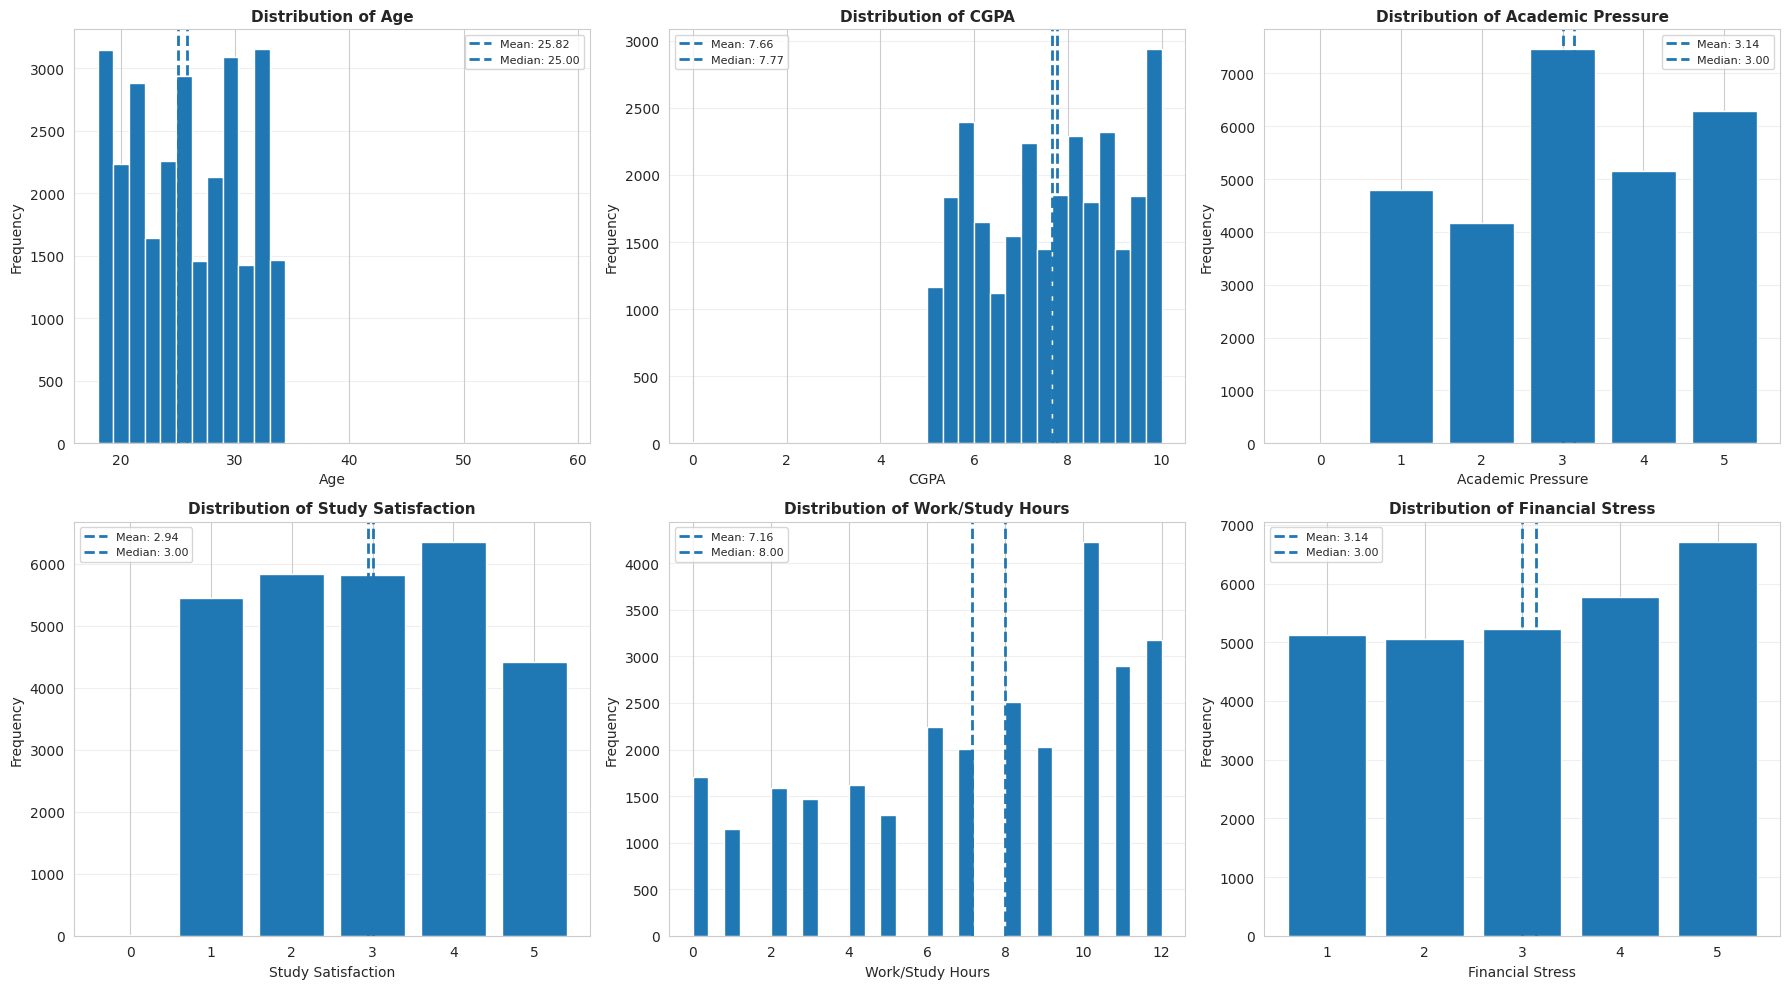

✓ Distributions saved successfully!


In [35]:
import math

num_features = len(numerical_features)
cols = 3
rows = math.ceil(num_features / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for idx, feature in enumerate(numerical_features):
    data = df_clean[feature].dropna()
    unique_vals = data.nunique()

    if unique_vals <= 10:
        # Discrete → Bar Plot
        vc = data.value_counts().sort_index()
        axes[idx].bar(vc.index, vc.values)
    else:
        # Continuous → Histogram
        axes[idx].hist(data, bins=30)

    # Titles & Labels
    axes[idx].set_title(f'Distribution of {feature}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(axis='y', alpha=0.3)

    # 📊 Statistics
    mean_val = data.mean()
    median_val = data.median()

    axes[idx].axvline(mean_val, linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[idx].axvline(median_val, linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')

    axes[idx].legend(fontsize=8)

for i in range(idx + 1, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.savefig('univariate_numerical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Distributions saved successfully!")

In [20]:
# Detailed interpretation of key numerical features
print("="*80)
print("NUMERICAL FEATURES - DETAILED INTERPRETATION")
print("="*80)

interpretations = {
    'Age': f'Mean age: {df_clean["Age"].mean():.1f} years. Range: {df_clean["Age"].min():.0f}-{df_clean["Age"].max():.0f}. Most students are young adults.',
    'Academic Pressure': f'Mean pressure: {df_clean["Academic Pressure"].mean():.1f}/5. Students report moderate to high academic pressure.',
    'Work Pressure': f'Mean pressure: {df_clean["Work Pressure"].mean():.1f}/5. Most values are 0-1, indicating low work pressure.',
    'CGPA': f'Mean CGPA: {df_clean["CGPA"].mean():.2f}/10. Academic performance is above average.',
    'Study Satisfaction': f'Mean: {df_clean["Study Satisfaction"].mean():.1f}/5. Moderate satisfaction with studies.',
    'Job Satisfaction': f'Mean: {df_clean["Job Satisfaction"].mean():.1f}/5. Generally low, as most are students.',
    'Sleep Duration': f'Mean: {df_clean["Sleep Duration"].mean():.1f} hours. Average student gets adequate sleep.',
    'Work/Study Hours': f'Mean: {df_clean["Work/Study Hours"].mean():.1f} hours/day. Varies widely ({df_clean["Work/Study Hours"].min():.0f}-{df_clean["Work/Study Hours"].max():.0f}).',
    'Financial Stress': f'Mean: {df_clean["Financial Stress"].mean():.1f}/5. Most report low to moderate financial stress.'
}

for feature, interpretation in interpretations.items():
    print(f"\n• {feature}: {interpretation}")

NUMERICAL FEATURES - DETAILED INTERPRETATION

• Age: Mean age: 25.8 years. Range: 18-59. Most students are young adults.

• Academic Pressure: Mean pressure: 3.1/5. Students report moderate to high academic pressure.

• Work Pressure: Mean pressure: 0.0/5. Most values are 0-1, indicating low work pressure.

• CGPA: Mean CGPA: 7.66/10. Academic performance is above average.

• Study Satisfaction: Mean: 2.9/5. Moderate satisfaction with studies.

• Job Satisfaction: Mean: 0.0/5. Generally low, as most are students.

• Sleep Duration: Mean: 6.4 hours. Average student gets adequate sleep.

• Work/Study Hours: Mean: 7.2 hours/day. Varies widely (0-12).

• Financial Stress: Mean: 3.1/5. Most report low to moderate financial stress.


## Binary Features Distribution

In [21]:
# Binary features statistics
print("="*80)
print("BINARY FEATURES - VALUE COUNTS")
print("="*80)

binary_labels = {
    'Gender': {1: 'Male', 0: 'Female'},
    'Have you ever had suicidal thoughts ?': {1: 'Yes', 0: 'No'},
    'Family History of Mental Illness': {1: 'Yes', 0: 'No'}
}

for feature in binary_features:
    print(f"\n{feature}:")
    counts = df_clean[feature].value_counts().sort_index()
    for value, count in counts.items():
        pct = (count / len(df_clean)) * 100
        label = binary_labels[feature].get(value, value)
        print(f"  {label:15s} ({value}): {count:6,d} ({pct:5.1f}%)")

BINARY FEATURES - VALUE COUNTS

Gender:
  Female          (0): 12,354 ( 44.3%)
  Male            (1): 15,547 ( 55.7%)

Have you ever had suicidal thoughts ?:
  No              (0): 10,245 ( 36.7%)
  Yes             (1): 17,656 ( 63.3%)

Family History of Mental Illness:
  No              (0): 14,398 ( 51.6%)
  Yes             (1): 13,503 ( 48.4%)


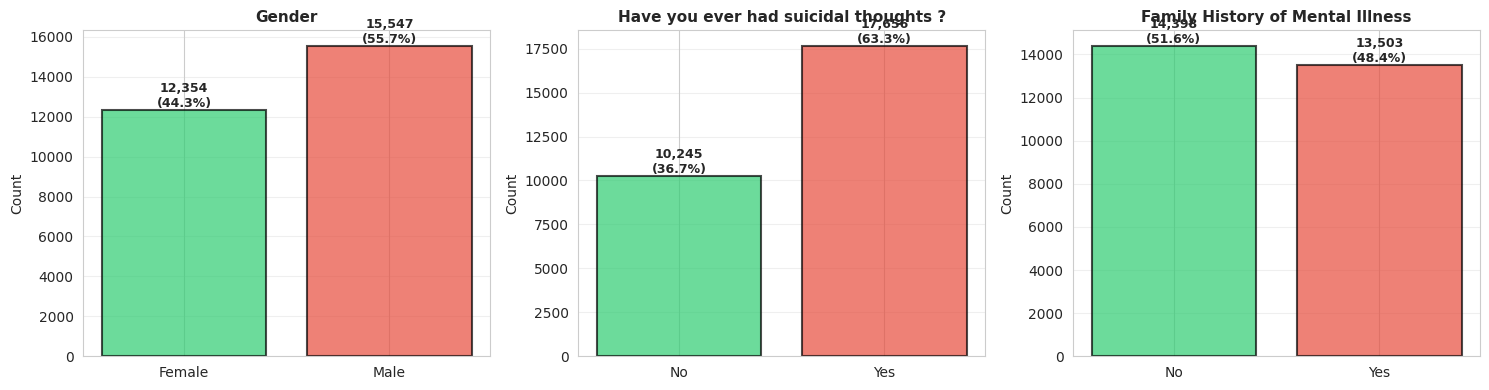

Binary features visualization saved!


In [22]:
# Visualize binary features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

binary_labels_list = [
    {1: 'Male', 0: 'Female'},
    {1: 'Yes', 0: 'No'},
    {1: 'Yes', 0: 'No'}
]

for idx, (feature, labels) in enumerate(zip(binary_features, binary_labels_list)):
    counts = df_clean[feature].value_counts().sort_index()

    # Create bar chart with actual labels
    bar_labels = [labels[i] for i in counts.index]
    bars = axes[idx].bar(bar_labels, counts.values, color=['#2ecc71', '#e74c3c'][:len(counts)],
                          edgecolor='black', alpha=0.7, linewidth=1.5)

    axes[idx].set_title(f'{feature}', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Count')
    axes[idx].grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for bar, value in zip(bars, counts.values):
        height = bar.get_height()
        pct = (value / len(df_clean)) * 100
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                       f'{value:,}\n({pct:.1f}%)',
                       ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('univariate_binary_features.png', dpi=300, bbox_inches='tight')
plt.show()

print("Binary features visualization saved!")

## Categorical Features Distribution

In [25]:
# High-cardinality categorical features - top categories
print("="*80)
print("CATEGORICAL FEATURES - TOP CATEGORIES")
print("="*80)

for feature in categorical_features:
    print(f"\n{feature} (Top 10):")
    print(f"Total unique values: {df_clean[feature].nunique()}")
    top_10 = df_clean[feature].value_counts().head(10)
    for i, (cat, count) in enumerate(top_10.items(), 1):
        pct = (count / len(df_clean)) * 100
        print(f"  {i:2d}. {str(cat):20s}: {count:6,d} ({pct:5.1f}%)")

CATEGORICAL FEATURES - TOP CATEGORIES

City (Top 10):
Total unique values: 52
   1. Kalyan              :  1,570 (  5.6%)
   2. Srinagar            :  1,372 (  4.9%)
   3. Hyderabad           :  1,340 (  4.8%)
   4. Vasai-Virar         :  1,290 (  4.6%)
   5. Lucknow             :  1,155 (  4.1%)
   6. Thane               :  1,139 (  4.1%)
   7. Ludhiana            :  1,111 (  4.0%)
   8. Agra                :  1,094 (  3.9%)
   9. Surat               :  1,078 (  3.9%)
  10. Kolkata             :  1,066 (  3.8%)

Profession (Top 10):
Total unique values: 14
   1. Student             : 27,870 ( 99.9%)
   2. Architect           :      8 (  0.0%)
   3. Teacher             :      6 (  0.0%)
   4. 'Digital Marketer'  :      3 (  0.0%)
   5. Chef                :      2 (  0.0%)
   6. 'Content Writer'    :      2 (  0.0%)
   7. Pharmacist          :      2 (  0.0%)
   8. Doctor              :      2 (  0.0%)
   9. 'UX/UI Designer'    :      1 (  0.0%)
  10. 'Civil Engineer'    :      1 (  0.

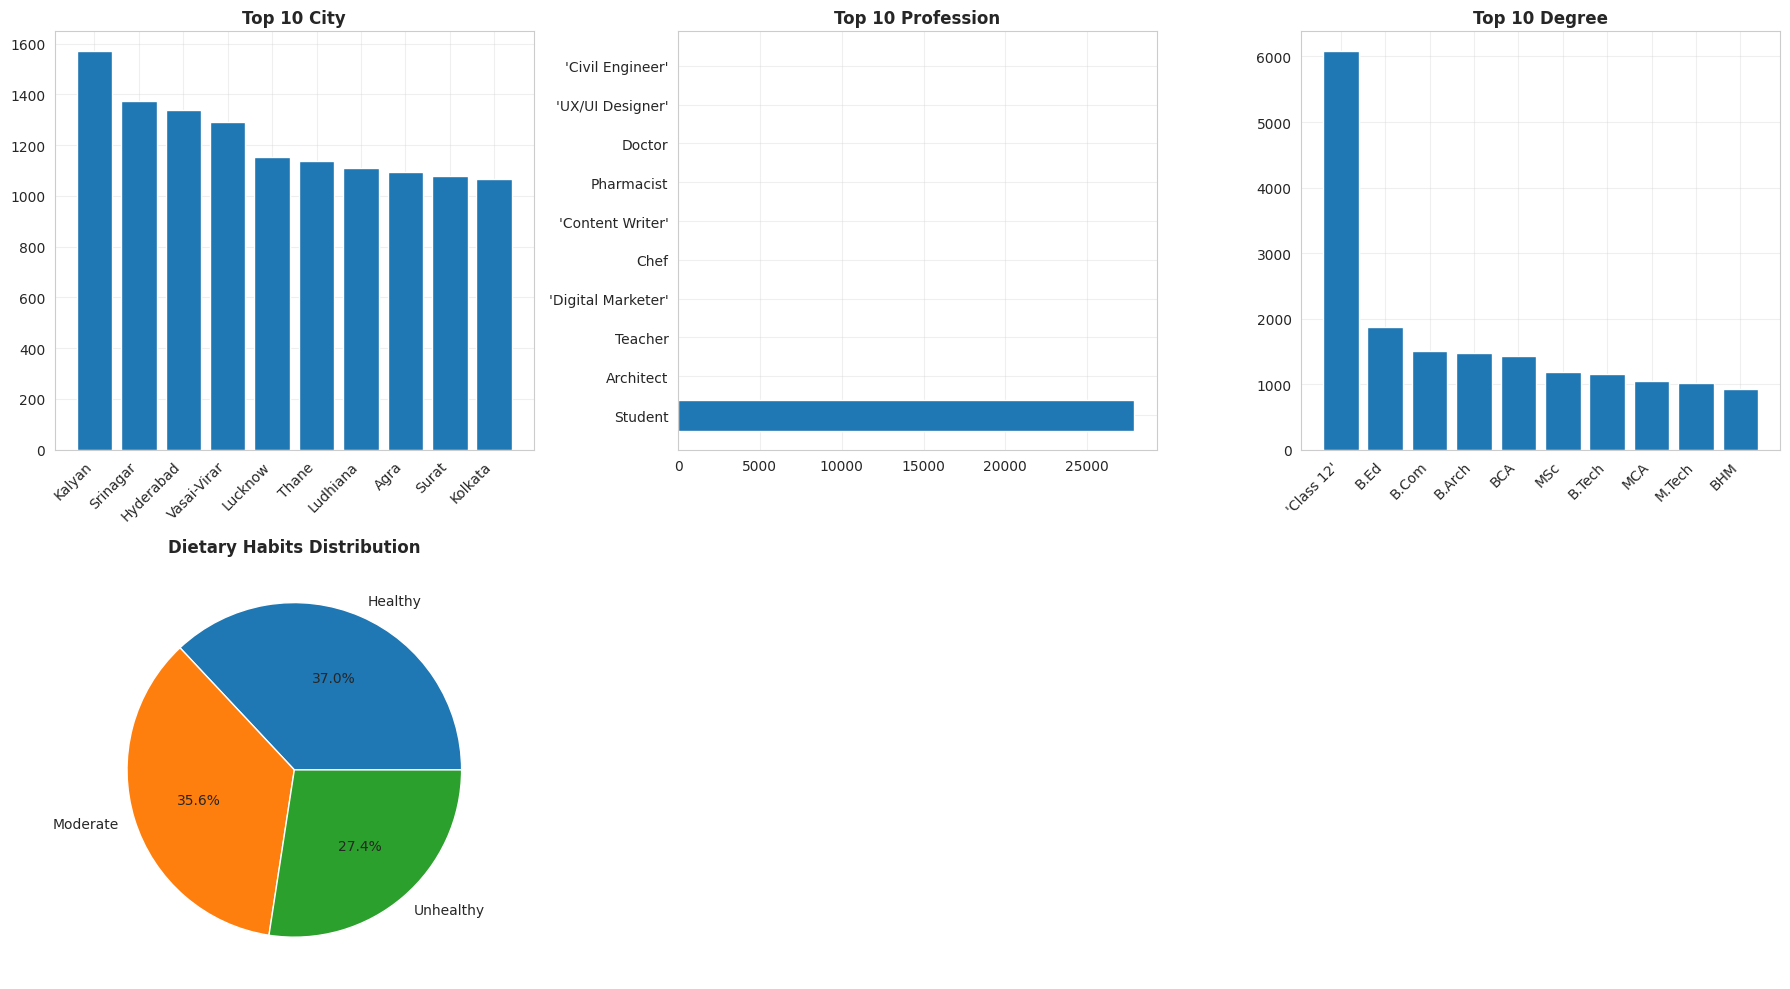

✓ Categorical visualizations generated successfully!


In [38]:
import math
import matplotlib.pyplot as plt

label_maps = {
    'Dietary Habits': {
        1: 'Healthy',
        2: 'Moderate',
        3: 'Unhealthy'
    },
    'Sleep Duration': {
        4: 'Less than 5 hours',
        5.5: '5-6 hours',
        7.5: '7-8 hours',
        9: 'More than 8 hours'
    }
}

num_features = len(categorical_features)
cols = 3
rows = math.ceil(num_features / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for idx, feature in enumerate(categorical_features):
    data = df_clean[feature].dropna()
    top_categories = data.value_counts().head(10)
    unique_vals = data.nunique()

    if feature in label_maps:
        labels = [label_maps[feature].get(i, str(i)) for i in top_categories.index]
    else:
        labels = [str(i) for i in top_categories.index]

    if unique_vals <= 5:
        axes[idx].pie(
            top_categories.values,
            labels=labels,
            autopct='%1.1f%%'
        )
        axes[idx].set_title(f'{feature} Distribution', fontweight='bold')

    elif unique_vals <= 15:
        axes[idx].barh(
            range(len(top_categories)),
            top_categories.values
        )
        axes[idx].set_yticks(range(len(top_categories)))
        axes[idx].set_yticklabels(labels)
        axes[idx].set_title(f'Top {len(top_categories)} {feature}', fontweight='bold')

    else:
        axes[idx].bar(
            range(len(top_categories)),
            top_categories.values
        )
        axes[idx].set_xticks(range(len(top_categories)))
        axes[idx].set_xticklabels(labels, rotation=45, ha='right')
        axes[idx].set_title(f'Top 10 {feature}', fontweight='bold')

    axes[idx].grid(alpha=0.3)

for i in range(idx + 1, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.savefig('categorical_features_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Categorical visualizations generated successfully!")

### 5.2 Bivariate Analysis: Features vs Depression

**Purpose:** Understand how individual features differ between depressed and non-depressed students.


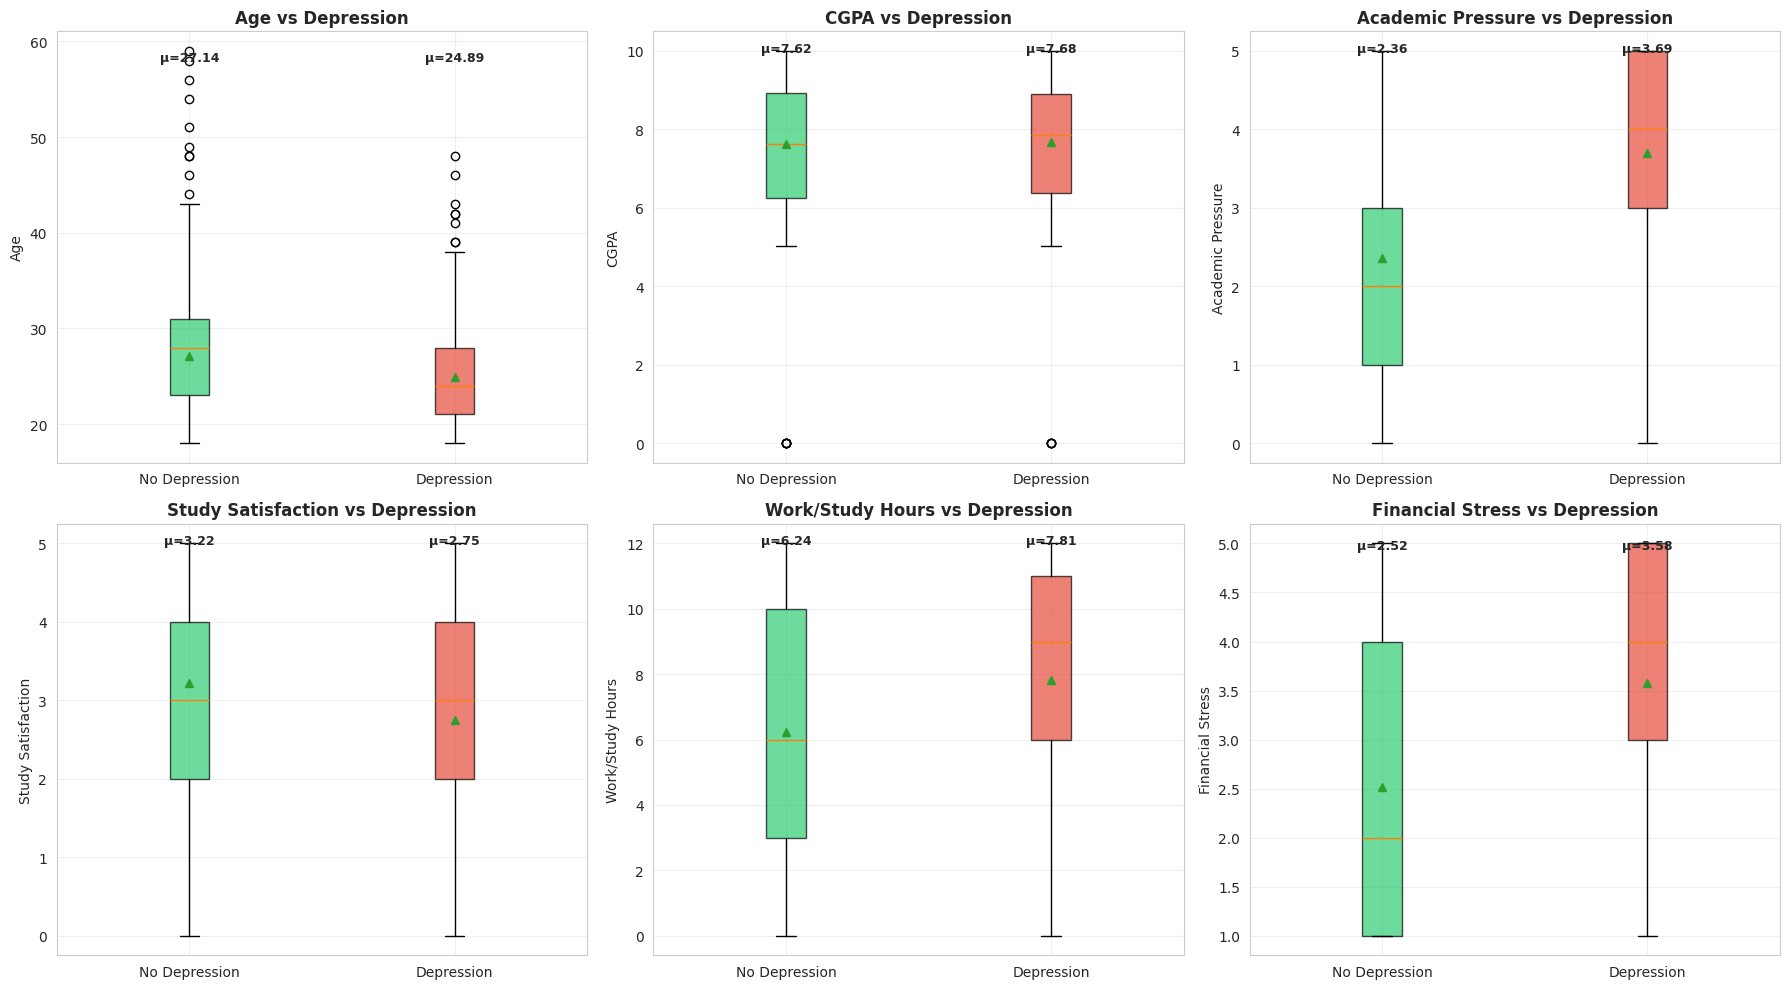


NUMERICAL FEATURES - DEPRESSION GROUP COMPARISON:

Age:
  No Depression  → Mean:   27.14, Std:    4.94
  Depression     → Mean:   24.89, Std:    4.66
  Difference     →    2.25

CGPA:
  No Depression  → Mean:    7.62, Std:    1.49
  Depression     → Mean:    7.68, Std:    1.45
  Difference     →    0.07

Academic Pressure:
  No Depression  → Mean:    2.36, Std:    1.25
  Depression     → Mean:    3.69, Std:    1.19
  Difference     →    1.33

Study Satisfaction:
  No Depression  → Mean:    3.22, Std:    1.33
  Depression     → Mean:    2.75, Std:    1.35
  Difference     →    0.46

Work/Study Hours:
  No Depression  → Mean:    6.24, Std:    3.86
  Depression     → Mean:    7.81, Std:    3.45
  Difference     →    1.57

Financial Stress:
  No Depression  → Mean:    2.52, Std:    1.35
  Depression     → Mean:    3.58, Std:    1.33
  Difference     →    1.06


In [30]:
# Bivariate analysis: Numerical features vs Depression
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

numerical_features = ['Age', 'CGPA', 'Academic Pressure', 'Study Satisfaction', 'Work/Study Hours', 'Financial Stress']

for idx, feature in enumerate(numerical_features):
    ax = axes[idx]

    # Box plot
    data_no_depression = df_clean[df_clean['Depression'] == 0][feature]
    data_with_depression = df_clean[df_clean['Depression'] == 1][feature]

    bp = ax.boxplot([data_no_depression, data_with_depression],
                     labels=['No Depression', 'Depression'],
                     patch_artist=True, showmeans=True)

    # Color the boxes
    for patch, color in zip(bp['boxes'], ['#2ECC71', '#E74C3C']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_title(f'{feature} vs Depression', fontsize=12, fontweight='bold')
    ax.set_ylabel(feature)
    ax.grid(True, alpha=0.3)

    # Add mean values as text
    mean_no = data_no_depression.mean()
    mean_yes = data_with_depression.mean()
    ax.text(1, ax.get_ylim()[1]*0.95, f'μ={mean_no:.2f}', ha='center', fontsize=9, fontweight='bold')
    ax.text(2, ax.get_ylim()[1]*0.95, f'μ={mean_yes:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("NUMERICAL FEATURES - DEPRESSION GROUP COMPARISON:")
print("=" * 80)

for feature in numerical_features:
    no_dep = df_clean[df_clean['Depression'] == 0][feature]
    has_dep = df_clean[df_clean['Depression'] == 1][feature]

    print(f"\n{feature}:")
    print(f"  No Depression  → Mean: {no_dep.mean():7.2f}, Std: {no_dep.std():7.2f}")
    print(f"  Depression     → Mean: {has_dep.mean():7.2f}, Std: {has_dep.std():7.2f}")
    print(f"  Difference     → {abs(has_dep.mean() - no_dep.mean()):7.2f}")

In [31]:
for col in numerical_features:
    print(f"\n{col}")
    print("NaN count:", df_clean[col].isna().sum())
    print("Unique sample:", df_clean[col].dropna().head(5).tolist())


Age
NaN count: 0
Unique sample: [33.0, 24.0, 31.0, 28.0, 25.0]

CGPA
NaN count: 0
Unique sample: [8.97, 5.9, 7.03, 5.59, 8.13]

Academic Pressure
NaN count: 0
Unique sample: [5.0, 2.0, 3.0, 3.0, 4.0]

Study Satisfaction
NaN count: 0
Unique sample: [2.0, 5.0, 5.0, 2.0, 3.0]

Work/Study Hours
NaN count: 0
Unique sample: [3.0, 3.0, 9.0, 4.0, 1.0]

Financial Stress
NaN count: 0
Unique sample: [1.0, 2.0, 1.0, 5.0, 1.0]
